# **Local Anonymization Smoke Test**

This notebook loads all `.jpg`, `.jpeg`, and `.png` images from the local `imgs/` directory and displays three versions of each image:

* Original image
* Detection preview with bounding boxes
* Final anonymized image with blur applied

In [73]:
import importlib
import sys
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
src_path = repo_root / "src"
config_path = repo_root / "configs" / "prod.yaml"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

for module_name in list(sys.modules):
    if module_name == "anonymizer.detectors" or module_name.startswith("anonymizer.detectors."):
        del sys.modules[module_name]

import anonymizer.blur as blur_module
import anonymizer.config as config_module
import anonymizer.detectors.factory as detectors_module

blur_module = importlib.reload(blur_module)
config_module = importlib.reload(config_module)
detectors_module = importlib.reload(detectors_module)

anonymize_image_bytes = blur_module.anonymize_image_bytes
decode_image = blur_module.decode_image
Settings = config_module.Settings
build_default_detector = detectors_module.build_default_detector

In [74]:
settings = Settings.from_yaml(config_path)

IMAGE_DIR = repo_root / "imgs"
VALID_SUFFIXES = (".jpg", ".jpeg", ".png")

FACE_DETECTOR_ENABLED = settings.face_detector_enabled
LICENSE_PLATE_DETECTION_MODEL = settings.license_plate_detection_model
LICENSE_PLATE_MODEL_FILE = settings.license_plate_model_file
LICENSE_PLATE_MIN_SCORE = settings.license_plate_min_score

BLUR_KERNEL_RATIO = settings.blur_kernel_ratio
MIN_BLUR_KERNEL = settings.min_blur_kernel

image_paths = sorted(
    path for path in IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in VALID_SUFFIXES
)

if not image_paths:
    raise RuntimeError(f"No images {VALID_SUFFIXES} found")

print(f"Found {len(image_paths)} images")

Found 6 images


In [75]:
detector = build_default_detector(
    license_plate_detection_model=LICENSE_PLATE_DETECTION_MODEL,
    license_plate_model_file=LICENSE_PLATE_MODEL_FILE,
    license_plate_min_score=LICENSE_PLATE_MIN_SCORE,
    face_detector_enabled=FACE_DETECTOR_ENABLED,
)

print("Detector ready")
print(f"RetinaFace enabled: {FACE_DETECTOR_ENABLED}")
print(f"License plate model: {LICENSE_PLATE_DETECTION_MODEL}")
print(f"License plate file: {LICENSE_PLATE_MODEL_FILE}")

Detector ready
RetinaFace enabled: True
License plate model: morsetechlab/yolov11-license-plate-detection
License plate file: license-plate-finetune-v1n.pt


In [76]:
BOX_COLORS = {
    "face": "#00A3FF",
    "license_plate": "#FF3B30",
}

def draw_detections(image: Image.Image, detections):
    preview = image.copy()
    draw = ImageDraw.Draw(preview)
    width, height = preview.size

    for detection in detections:
        x1, y1, x2, y2 = detection.clamped(width=width, height=height)
        color = BOX_COLORS.get(detection.label, "#FFD60A")
        draw.rectangle((x1, y1, x2, y2), outline=color, width=4)

        label = f"{detection.label} {detection.score:.2f}"
        text_bbox = draw.textbbox((x1, y1), label)
        text_height = text_bbox[3] - text_bbox[1]
        label_y = max(0, y1 - text_height - 6)
        draw.rectangle((x1, label_y, x1 + text_bbox[2] - text_bbox[0] + 8, label_y + text_height + 6), fill=color)
        draw.text((x1 + 4, label_y + 3), label, fill="white")

    return preview

In [77]:
from collections import Counter

results = []

for image_path in image_paths:
    image_bytes = image_path.read_bytes()
    image_rgb = decode_image(image_bytes)
    original = Image.fromarray(image_rgb)

    detections = detector.detect(image_rgb)
    detected = draw_detections(original, detections)

    anonymized_bytes = anonymize_image_bytes(
        image_bytes,
        detections,
        blur_kernel_ratio=BLUR_KERNEL_RATIO,
        min_blur_kernel=MIN_BLUR_KERNEL,
    )
    anonymized = Image.open(BytesIO(anonymized_bytes)).convert("RGB")

    results.append({
        "name": image_path.name,
        "original": original,
        "detected": detected,
        "anonymized": anonymized,
        "detections": detections,
    })

    counts = Counter(d.label for d in detections)

    if counts:
        labels_str = ", ".join(f"{k}:{v}" for k, v in counts.items())
    else:
        labels_str = "none"

    print(f"{image_path.name:30} | detections={len(detections):2d} | {labels_str}")

00330.jpg                      | detections= 0 | none
7d6c1119-00000000.jpg          | detections= 1 | license_plate:1
7dc08598-f42e2015.jpg          | detections= 2 | face:1, license_plate:1
7ff455ce-00000000.jpg          | detections= 3 | license_plate:3
b2e9eaa4-00000000.jpg          | detections= 5 | license_plate:5
d458cf06-00000000.jpg          | detections= 1 | license_plate:1


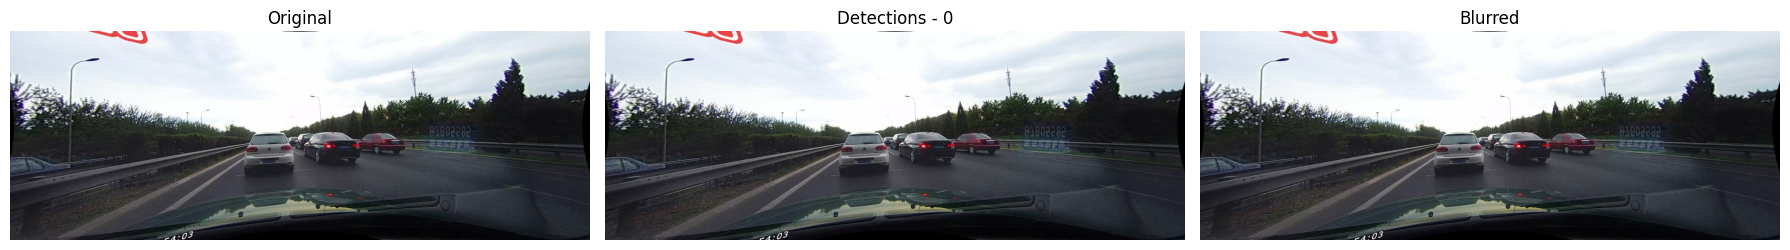

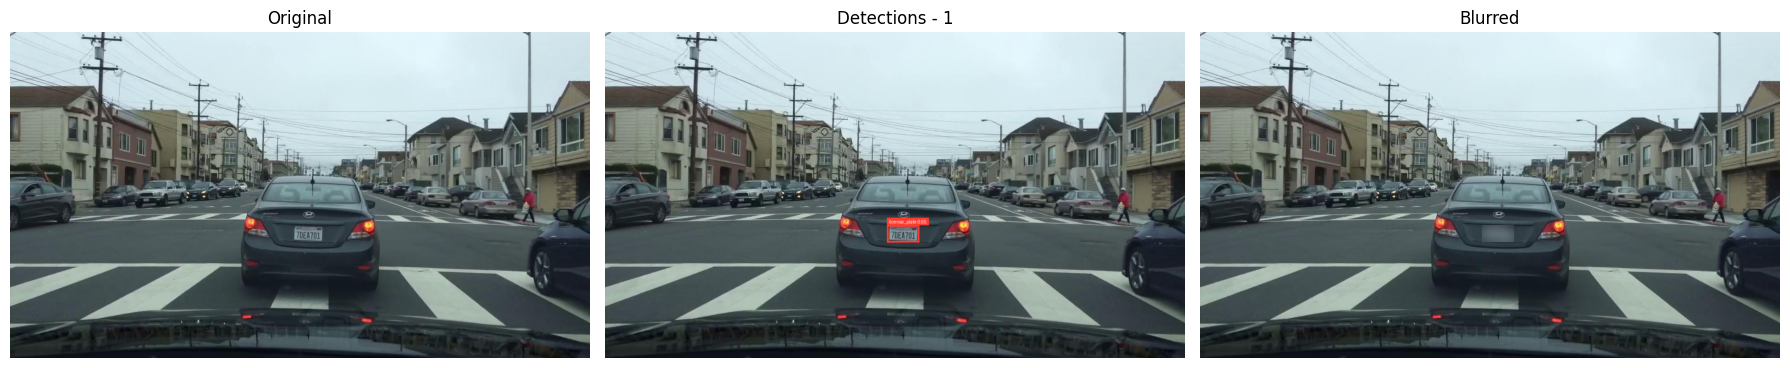

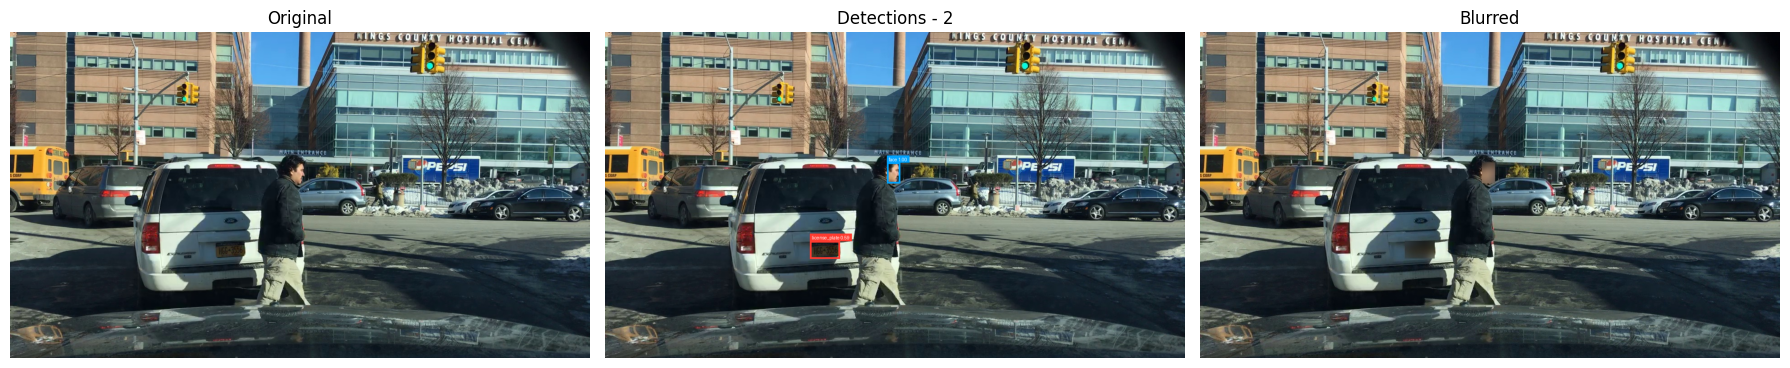

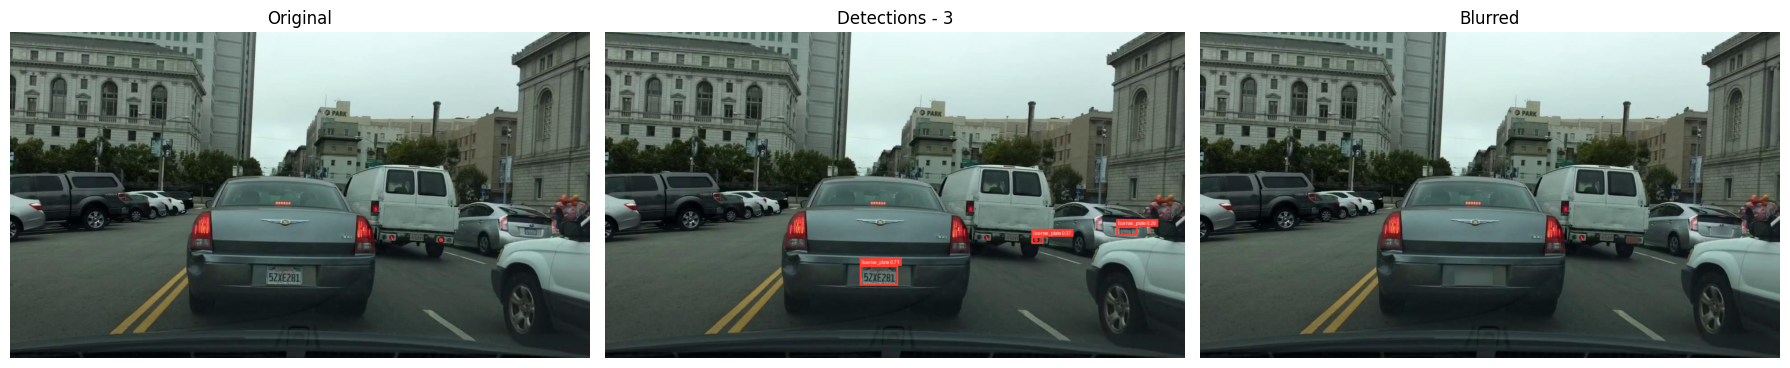

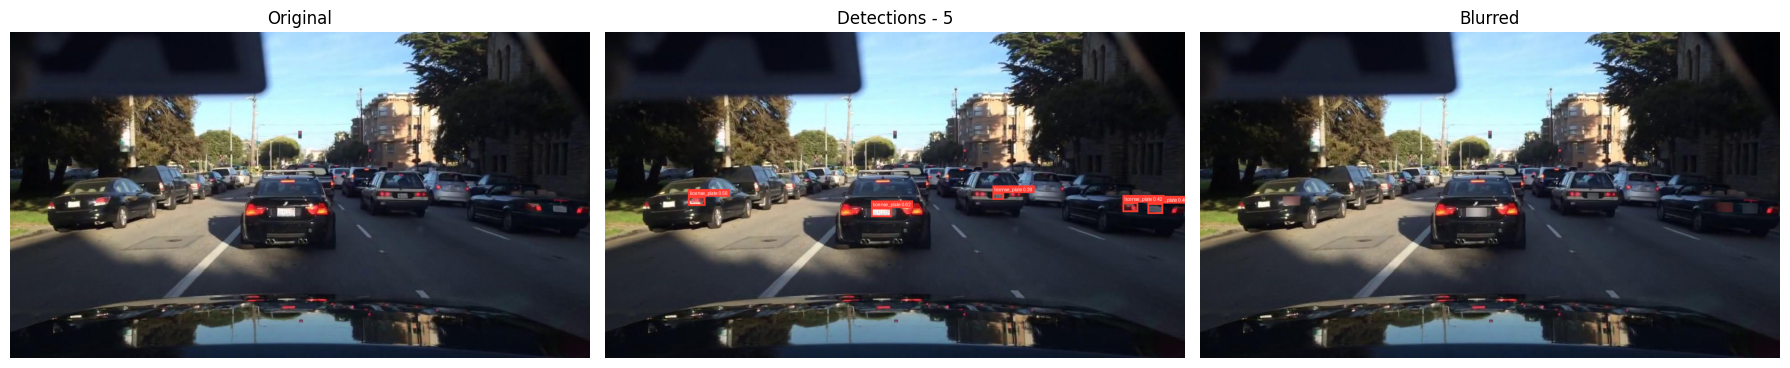

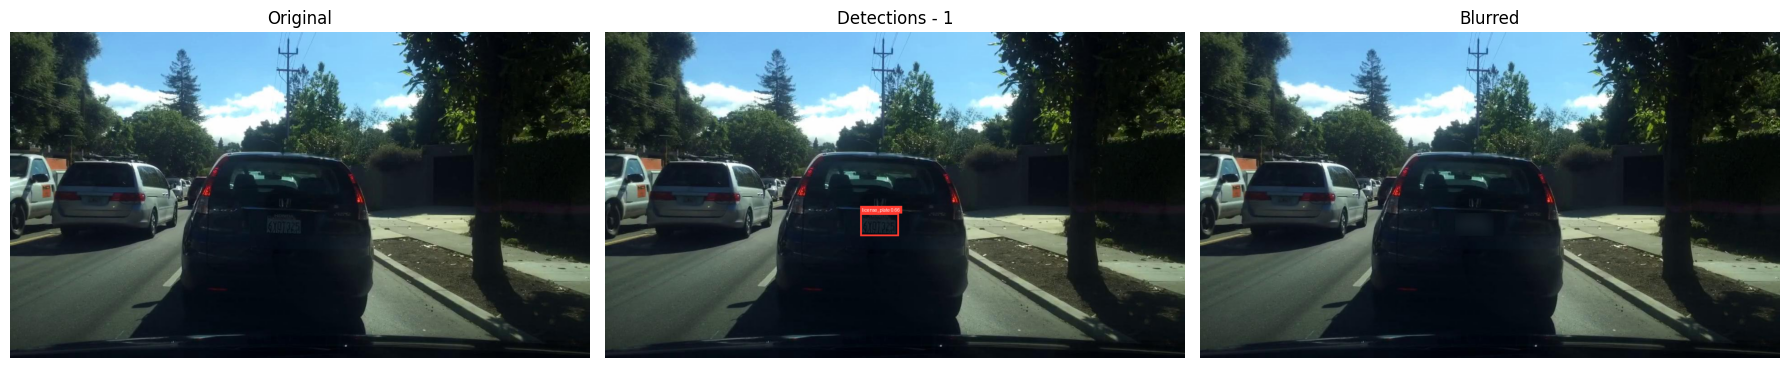

In [78]:
for item in results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(item["original"])
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(item["detected"])
    axes[1].set_title(f"Detections - {len(item['detections'])}")
    axes[1].axis("off")

    axes[2].imshow(item["anonymized"])
    axes[2].set_title("Blurred")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()